In [2]:
# ============================================================
# LIME EXPLAINABILITY DEMO FOR FINANCE STUDENTS
# Loan Approval / Denial Prediction
# ============================================================

# This notebook demonstrates:
# 1. Building a loan approval ML model
# 2. Predicting loan approval
# 3. Explaining individual predictions using LIME
# 4. Visualizing important features


# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from lime.lime_tabular import LimeTabularExplainer

import warnings
warnings.filterwarnings("ignore")


In [3]:


# ============================================================
# STEP 2: CREATE SYNTHETIC FINANCE DATASET
# ============================================================

np.random.seed(42)

n = 1000

income = np.random.normal(60000, 15000, n).astype(int)
credit_score = np.random.normal(650, 80, n).astype(int)
loan_amount = np.random.normal(25000, 10000, n).astype(int)
years_employed = np.random.randint(0, 20, n)
existing_debt = np.random.normal(15000, 8000, n).astype(int)

# Create loan approval logic
approval = []

for i in range(n):

    score = 0

    if income[i] > 50000:
        score += 1

    if credit_score[i] > 680:
        score += 1

    if loan_amount[i] < 30000:
        score += 1

    if years_employed[i] > 5:
        score += 1

    if existing_debt[i] < 20000:
        score += 1

    if score >= 3:
        approval.append("Approved")
    else:
        approval.append("Denied")


# Create DataFrame
df = pd.DataFrame({
    "Income": income,
    "CreditScore": credit_score,
    "LoanAmount": loan_amount,
    "YearsEmployed": years_employed,
    "ExistingDebt": existing_debt,
    "LoanStatus": approval
})

print(df.head())



   Income  CreditScore  LoanAmount  YearsEmployed  ExistingDebt LoanStatus
0   67450          761       18248              8         24901   Approved
1   57926          723       23554              6         26031   Approved
2   69715          654       17075             14         12862   Approved
3   82845          598       21920              1         18705   Approved
4   56487          705        6063             19         12124   Approved


In [ ]:

# ============================================================
# STEP 3: VISUALIZE THE DATASET
# ============================================================

print("\nDataset Shape:", df.shape)

# Loan Approval Distribution
plt.figure(figsize=(6,4))
df["LoanStatus"].value_counts().plot(kind="bar")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()


# Credit Score Distribution
plt.figure(figsize=(7,4))
plt.hist(df["CreditScore"], bins=20)
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()


# Income vs Loan Amount
plt.figure(figsize=(7,5))
plt.scatter(df["Income"], df["LoanAmount"])
plt.title("Income vs Loan Amount")
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.show()


In [4]:
# ============================================================
# STEP 4: PREPARE DATA
# ============================================================

X = df.drop("LoanStatus", axis=1)

y = df["LoanStatus"]

# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)




Training Shape: (800, 5)
Testing Shape: (200, 5)


In [5]:
# ============================================================
# STEP 5: TRAIN MACHINE LEARNING MODEL
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))




Accuracy: 0.99

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       162
           1       1.00      0.95      0.97        38

    accuracy                           0.99       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.99      0.99      0.99       200




Feature Importance:

         Feature  Importance
0         Income    0.219797
3  YearsEmployed    0.218931
2     LoanAmount    0.204191
4   ExistingDebt    0.198309
1    CreditScore    0.158772


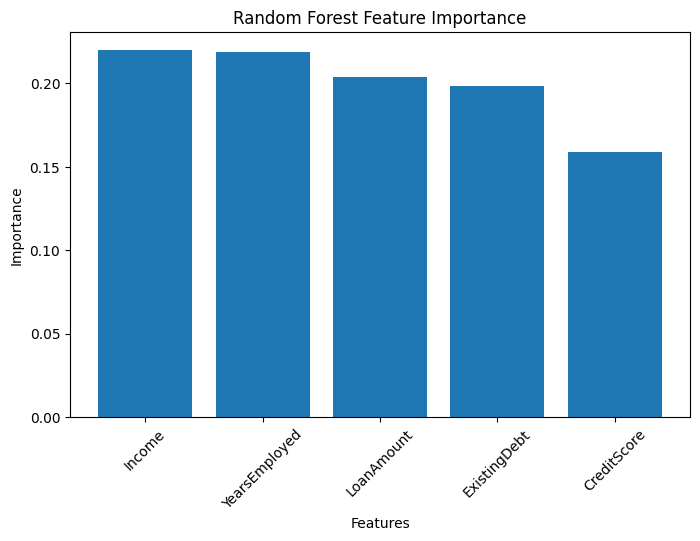

In [6]:
# ============================================================
# STEP 6: FEATURE IMPORTANCE VISUALIZATION
# ============================================================

importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:\n")
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(8,5))
plt.bar(feature_importance_df["Feature"],
        feature_importance_df["Importance"])

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()


In [9]:


# ============================================================
# STEP 7: LIME EXPLAINER
# ============================================================

explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns.tolist(),
    class_names=encoder.classes_,
    mode='classification'
)



In [10]:

# ============================================================
# STEP 8: EXPLAIN A SINGLE LOAN DECISION
# ============================================================

# Choose one test instance
instance_index = 5

instance = X_test.iloc[instance_index]

print("\n===================================================")
print("Loan Application to Explain")
print("===================================================\n")

print(instance)

# Actual prediction
prediction = model.predict([instance])[0]

predicted_class = encoder.inverse_transform([prediction])[0]

print("\nPredicted Decision:", predicted_class)



Loan Application to Explain

Income           74035
CreditScore        729
LoanAmount       25953
YearsEmployed        3
ExistingDebt     17046
Name: 678, dtype: int32

Predicted Decision: Approved


In [11]:
# ============================================================
# STEP 9: GENERATE LIME EXPLANATION
# ============================================================

exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=model.predict_proba,
    num_features=5
)

print("\n===================================================")
print("LIME Explanation")
print("===================================================\n")

for feature, weight in exp.as_list():
    print(f"{feature:40} --> {weight:.4f}")


LIME Explanation

YearsEmployed <= 5.00                    --> 0.3106
CreditScore > 707.25                     --> -0.1386
Income > 69690.25                        --> -0.1141
14961.00 < ExistingDebt <= 20316.00      --> -0.0970
25022.50 < LoanAmount <= 31804.75        --> -0.0266


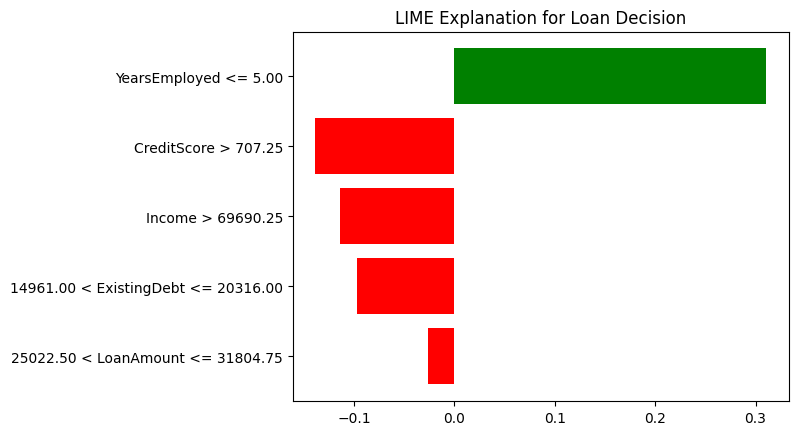

In [12]:
# ============================================================
# STEP 10: VISUALIZE LIME EXPLANATION
# ============================================================

exp.as_pyplot_figure()

plt.title("LIME Explanation for Loan Decision")
plt.show()


In [13]:
# ============================================================
# STEP 11: OPTIONAL - SAVE HTML EXPLANATION
# ============================================================

# This creates an interactive HTML file
# that students can open in browser

exp.save_to_file("lime_loan_explanation.html")

print("\nInteractive HTML explanation saved!")
print("File Name: lime_loan_explanation.html")




Interactive HTML explanation saved!
File Name: lime_loan_explanation.html


```
1. LIME explains INDIVIDUAL predictions.

2. The model may approve one person because:
   - High income
   - Good credit score
   - Low debt

3. Another person may be denied because:
   - Poor credit score
   - High debt
   - Large loan amount

4. LIME does NOT explain the entire model.
   It explains ONE prediction at a time.

5. Positive values push toward approval.
   Negative values push toward denial.

6. This is important in finance because:
   - Banks need transparency
   - Regulations require explanations
   - Customers may ask:
     'Why was my loan denied?'
